In [ ]:
# Bibliotecas que serão usadas no projeto
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import butter, resample_poly, savgol_filter, sosfilt, sosfilt_zi
from sklearn.linear_model import (
    Lasso,
    LassoCV,
    LinearRegression,
    MultiTaskLassoCV,
    Ridge,
    RidgeCV,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler  # type: ignore

# RNG padrão para reprodutibilidade
rng = np.random.default_rng(42)


---
### <a id='toc1_1_4_'></a>[L2: penalização nos pesos](#toc0_)

Para resolver os problemas mal-condicionados devemos saber como escolher os coeficientes. Para isso, a função de penalização deve forçar hipóteses na estrutura do espaço de solução e ter preferencias que façam com que soluções indiferenciáveis se tornem diferenciáveis. Mas como essa função se comporta?

Imagine que modifiquemos a função de custo para a forma vista em (2) (o fator de $\frac{1}{2}$ é posto apenas para facilitar a derivação). O termo final é algo deliberadamente inserido para ampliar a pergunta da loss original: vamos de **Qual o melhor w que explica o problema** para **Qual o melhor w que explica o problema e gera coeficientes balanceados** <a id='toc0_'></a>[[1]](#toceq_1_) <a id='toc0_'></a>[[3]](#toceq_3_). Isso é a ideia que L2 introduz e para representar isso no espaço de solução adicionamos um termo como visto na equação (2).

$$(2)\qquad J_{Ridge}(w)=\frac{1}{2}||Xw-y||_2^2+\frac{\lambda}{2}||w||_2^2$$

Desenvolvendo o último termo, a função de penalização dos pesos surge naturalmente

$$||w||_2^2=w^{\dagger}w=w^Tw=\sum_i w_i^2=R(w)$$

Interpretando essa função, ela penalizando pesos muito altos, já que seu crescimento é de forma quadrática. Por isso, a função de L2 da preferencia a respostas distribuídas entre os termos, algo que a função loss original não possui.

Com o $R(w)$, podemos usar a equação (2) para derivar o gradiente dessa função. Como $R(w)$ tem a mesma forma geral de $J(w)$ (no sentido de ambos serem funções de $f(x)=||x||_2^2$), elas são deriváveis, por isso, o seu gradiente é dado por (todos os $\dagger$ serão substituídos por $T$, já que, nesse cenário, são iguais):

$$\nabla J_{L2}(w)= \nabla (\frac{1}{2}||Xw-y||_2^2+\frac{\lambda}{2}||w||_2^2)= \nabla(\frac{1}{2}(Xw-y)^T(Xw-y)+\frac{\lambda}{2}w^Tw)$$

O primeiro termo fica

$$\nabla\frac{1}{2}(Xw-y)^T(Xw-y)=\nabla\frac{1}{2}(w^TX^TXw-w^TX^Ty-y^TXw+y^Ty)$$

Como $w^TX^Ty$ é escalares, temos que $w^TX^Ty=(w^TX^Ty)^T=y^TXw$

$$\nabla\frac{1}{2}(Xw-y)^T(Xw-y)=\nabla\frac{1}{2}(w^TX^TXw-2y^TXw-y^Ty)=X^TXw-X^Ty=\nabla J(w)$$

Agora, desenvolvendo o segundo termo

$$\nabla R(w)=\nabla\frac{\lambda}{2}w^Tw=\lambda w$$

Rearranjando os termos, temos que o gradiente da função $J_{L2}(w)$ é dado por (3).

$$(3)\qquad \nabla J_{L2}(w) = X^T(Xw-y)+\lambda w$$

Agora, podemos achar o mínimo do gradiente, que será no:

$$(4)\qquad X^T(Xw-y)+\lambda w = 0 \rightarrow (X^TX + \lambda I)w=X^Ty \rightarrow w_{Ridge}=(X^TX + \lambda I)^{-1}X^Ty$$

Nota-se que, se não tivéssemos um termo a mais, o passo final dessa operação assume que $X^TX$ é uma matriz inversível. Porém, a vantagem do Ridge (a regularização L2) é que precisamos assumir que $(X^TX+\lambda I)$ é inversível. Não desenvolveremos isso aqui, mas, mesmo quando $X^TX$ é singular, o termo anterior sempre é inversível para $\lambda >0$, o que é algo incrivelmente valioso do método. Quando $\lambda I$ é somado a $X^TX$, ele aumenta a diagonal principal, tornando a matriz mais resistente a singularidade pois aumenta o autovalor ($\sigma_i^2$) em um fator de $\lambda$. Isso permite que o passo do gradiente seja mais comportado e estável, analisando o resultado por decomposição SVD (decompondo $X$ em $U\Sigma V^T$) <a id='toc0_'></a>[{2}](#tocap_2_), nota-se que o passo $w_i$ é proporcional a $\frac{\sigma_i}{\sigma_i^2+\lambda}$ <a id='toc0_'></a>[[3]](#toceq_3_). Com isso, nos extremos temos:

$$\text{para }\sigma_i^2 \gg \lambda\text{, temos: }\frac{\sigma_i}{\sigma_i^2+\lambda}\approx \frac{1}{\sigma_i} \\ \text{para }\sigma_i^2 \ll \lambda\text{, temos: }\frac{\sigma_i}{\sigma_i^2+\lambda}\approx \frac{\sigma_i}{\lambda}$$

Para visualizarmos, veja o gráfico abaixo.

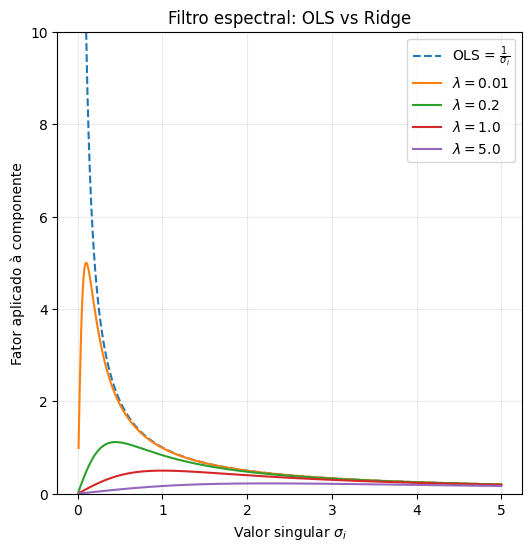

In [ ]:
# Valores singulares
sigma=np.linspace(0.01, 5, 1000)

#valores reguladores
lambdas=[0.01, 0.2, 1.0, 5.0]

ols_filter= 1/sigma

plt.figure(figsize=(6,6))

plt.plot(sigma, ols_filter, linestyle="--", label=r"OLS = $\frac{1}{\sigma_i}$")

for lam in lambdas:
    ridge_filter = sigma/(sigma**2 + lam)

    plt.plot(
        sigma,
        ridge_filter,
        label= rf"$\lambda ={lam}$"
    )


plt.xlabel(r"Valor singular $\sigma_i$")
plt.ylabel("Fator aplicado à componente")
plt.title("Filtro espectral: OLS vs Ridge")

plt.ylim(0, 10)
plt.grid(alpha=0.25)
plt.legend()

plt.show()


Veja como para o OLS comum, valores singulares muito pequenos e não nulos acabam explodindo quando $\sigma_i\to 0^+$, amplificando componentes associadas a direções mal determinadas. Já quando adicionamos o fator de $\lambda$, isso se torna mais comportado.

Assim, vemos que o L2 é uma boa solução para o problema da decisão entre variáveis correlacionadas ao estabilizar a solução, mas nem sempre é fácil encontrar o $min_w(||Xw-y||_2^2+\lambda||w||_2^2)$. Para situações como essa, existem técnicas que analisam a geometria do espaço de soluções do L2, na qual minimiza-se o termo $||Xw-y||_2^2$ e restringe-se a função $R(w)$ com uma constante $C$, resultando na forma (5). Para cada $\lambda$ existe uma formulação correspondente de $C$ e vice-versa <a id='toc0_'></a>[[3]](#toceq_3_) <a id='toc0_'></a>[[6]](#toceq_6_).

$$(5)\qquad \text{Ache }min(||Xw-y||_2^2)\text{ com }\sum_i w_i^2\leq C$$

Como isso se comporta no espaço da Loss? Para analisar isso, imagine uma função loss artificial com mínimos em $(2,0.5)$ (os números são arbitrários, poderiam ser substituídos por qualquer outros valores). Ademais, essa loss tera um comportamento do tipo:

$$J(w_1, w_2)=(w_1-2)^2+2(w_2-0.5)^2$$

Mais uma vez, tudo escolhido é completamente arbitrário, particularmente os coeficientes de $w_1$ e $w_2$ foram propositalmente escolhidos para serem diferentes. Isso gera uma loss elíptica, tornando mais geral o conceito que queremos discorrer abaixo.

In [ ]:
# Espaço dos parâmetros
w1= np.linspace(-3, 3, 400)
w2= np.linspace(-3, 3, 400)

# Combinação de parâmetros
W1, W2 = np.meshgrid(w1, w2)

# Loss artificial
J=(W1-2)**2+2*(W2-0.5)**2

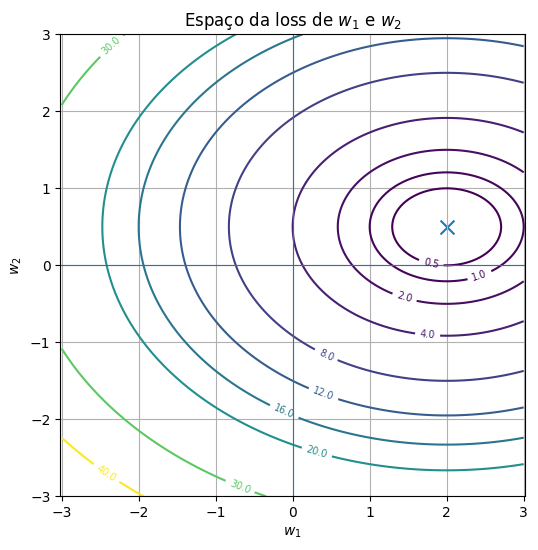

In [ ]:
plt.figure(figsize=(6,6))

contorno = plt.contour(
    W1,
    W2,
    J,
    levels=[0.5, 1, 2, 4, 8, 12, 16, 20, 30, 40]
)

plt.clabel(contorno, inline=True, fontsize=7)

plt.scatter(2, 0.5, marker="x", s=100)

plt.xlabel(r"$w_1$")
plt.ylabel(r"$w_2$")
plt.title(r"Espaço da loss de $w_1$ e $w_2$")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.axis("equal")
plt.grid()
plt.show()

Aqui vemos varias elipses centradas em $(2, 0.5)$, cada uma aumentando a loss na medida em que se afastam de seu centro. Contudo, note que a região permitida pela restrição do L2 não está centrado em $(2, 0.5)$, ele parte do $(0,0)$, isso resulta em algo interessante demonstrado abaixo.

Para construir a região $w_1^2 + w_2^2\leq C$, usaremos um theta para calcular $w_1$ e $w_2$. Além disso, vamos escolher um $C<||(2,0.5)||_2^2$, já que isso resultará em uma análise interessante.

In [ ]:

theta=np.linspace(0, 2*np.pi, 500)

#Raio arbitrário
r=1
#Para esclarecimento, r²=C

l2_w1=r*np.cos(theta)
l2_w2=r*np.sin(theta)

#Essa mascara define quais combinações de pontos podem entrar na consideração da solução ótima
mask_l2=W1**2 + W2**2 <= r**2


In [ ]:
# Achando a solução pelo método L2
J_l2=np.where(mask_l2, J ,np.inf)
idx_l2 = np.unravel_index(np.argmin(J_l2), J_l2.shape)
w_l2= (W1[idx_l2],W2[idx_l2])

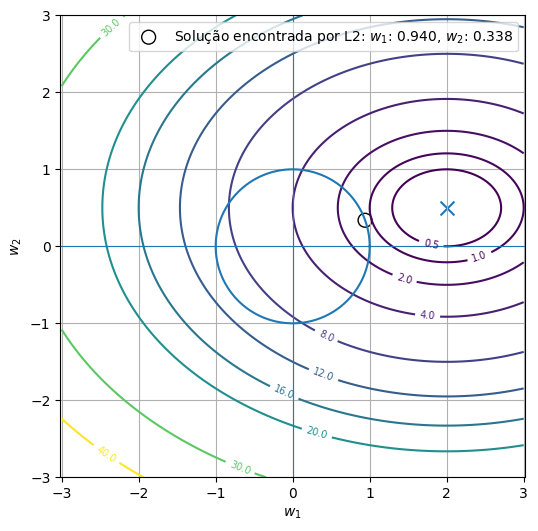

In [ ]:
plt.figure(figsize=(6, 6))

contorno = plt.contour(
    W1,
    W2,
    J,
    levels=[ 0.5, 1, 2, 4, 8, 12, 16, 20, 30, 40]
)

plt.clabel(contorno, inline=True, fontsize=7)

plt.plot(l2_w1, l2_w2)

plt.scatter(2, 0.5, marker="x", s=100)
plt.scatter(w_l2[0], w_l2[1], marker="o", facecolor="none", edgecolors="black", s=100, label= fr"Solução encontrada por L2: $w_1$: {w_l2[0]:.3f}, $w_2$: {w_l2[1]:.3f}")

plt.xlabel(r"$w_1$")
plt.ylabel(r"$w_2$")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.axis("equal")
plt.legend()
plt.grid()
plt.show()

(5) define uma n-bola, que é uma forma geral de uma esfera preenchida de n dimensões, disponível para a busca (o caso usado é bidimensional, mas é fácil notar a generalização para dimensões superiores). Para um dado $\sum_i w_i^2=C$ a solução ótima existe na tangente da curva de nível $J(w)=c$ (não confundir $c$ com $C$) que tangencia a n-bola externamente, caso a solução ótima esteja fora do espaço de admissão. Como essa hiperesfera é suave, essa solução, normalmente, se encontra distante dos eixos puros <a id='toc0_'></a>[[3]](#toceq_3_), geralmente ela não favorece soluções de coeficiente zero.

Contudo, o computador não consegue, sempre, zerar o gradiente por ser uma operação computacionalmente cara para problemas muito grandes, tornando, as vezes, inviável o computar. Por isso, usa-se uma técnica chamada *Gradient Descent*, em que usa-se o gradiente atual para 'caminhar' em direção de uma minimização da loss. Abandonando o formalismo matricial, podemos escrever (3) como a equação (6). Nesse contexto, vamos abandonar a convenção do $\frac{1}{2}$, já que a literatura sobre Weight Decay não a usa e não há impacto na validade do resultado usar esse termo ou não.

$$(6)\qquad \nabla J_{L2}(w_t)=\frac{\partial J(w_t)}{\partial w} + 2\lambda w_t$$


Então, os novos pesos $w_{t+1}$ dessa equação são dados por $w_{t+1}=w_t-\eta(\nabla J_{L2}(w_t))$ que se expande para a equação (7).

$$(7)\qquad
w_{t+1}= (1-2\lambda \eta) w_t - \eta\frac{\partial J}{\partial w}$$

Isso simboliza algo muito importante, a cada atualização, o peso sofre uma contração segundo o termo $(1-2\lambda \eta) w_t$. Tal ocorrência da o nome para esse tipo de técnica de Weight Decay <a id='toc0_'></a>[[4]](#toceq_4_), em que os pesos passam a importar quando entra-se no domínio de loss baixa. Dentro desse domínio, a função ajusta os pesos com pouca variação de $J(w)$.

Isso resolve de uma forma muito elegante o problema do mal-condicionamento, como $X^TX+\lambda I$ é sempre inversível para $\lambda>0$, todo caso tem uma solução fechada no L2, dentro dos problemas abordados nesse notebook. Esse fato não só é bom para mal-condicionamento, ele estruturalmente resolve o problema do sub-determinação. Contudo, essa é a melhor forma de resolver o problema?

---
### <a id='toc1_1_5_'></a>[L1: regularização geométrica](#toc0_)



L1 é, de certa forma, quase que idêntico ao L2, alterando somente o termo $R(w)$. Contudo, qual outra característica que seria desejada numa outra função? Mesmo que L2 gere pesos distribuídos e possamos usar a técnica da restrição geométrica do espaço, ele ainda assim não tenta minimizar o somatório dos pesos caso isso custe muita loss. A pergunta agora é **e se a solução não tem uma contribuição útil vinda de alguns poucos pesos?**

L1 não deseja distribuir os pesos, ele quer gerar esparsidade no espaço de soluções, mas como fazer isso? É necessário punir pesos baixos mais violentamente para que o máximo de zeros apareça quando o peso não contribui para a solução. Para isso, usa-se uma outra minimização sem ser a $||w||_2^2$ (para manter a mesma derivação feita em (2), porém, como não há necessidade de se preocupar com a derivação de $R(w)$ nesse caso, não sera adicionado o $\frac{1}{2}$ nele):

$$J_{L1}(w)=\frac{1}{2}||Xw-y||_2^2+\lambda ||w||_1$$

O último termo pode ser desenvolvido facilmente para:

$$R(w)=||w||_1=\sum_{i=1}^{p} |w_i|$$

De forma análoga a feita na seção de L2, podemos restringir a geometria do problema para compreender como que essa função se comporta no quesito do deslocamento no hyperespaço da loss. Ao aplicar a mesma restrição que fizemos em L2, obtemos a equação (8).

$$(8)\qquad |w_1|+|w_2|+...|w_p|\leq C$$

Para, novamente, facilitarmos a visualização desse conceito, veja abaixo o gráfico formado por essa equação em um caso bidimensional.

In [ ]:
C = 1

#Note que o ultimo termo é igual ao primeiro nos dois, isso é para a forma geométrica se completar, já que o matplotlib não faz isso por conta própria.
l1_w1 = np.array([C, 0, -C, 0, C])
l1_w2 = np.array([0, C, 0, -C, 0])

#Essa mascara define quais combinações de pontos podem entrar na consideração da solução ótima
mask_l1 = np.abs(W1)+np.abs(W2)<= C

In [ ]:
#achando a solução pelo método l1
J_l1=np.where(mask_l1, J ,np.inf)
idx_l1 = np.unravel_index(np.argmin(J_l1), J_l1.shape)
w_l1= (W1[idx_l1],W2[idx_l1])

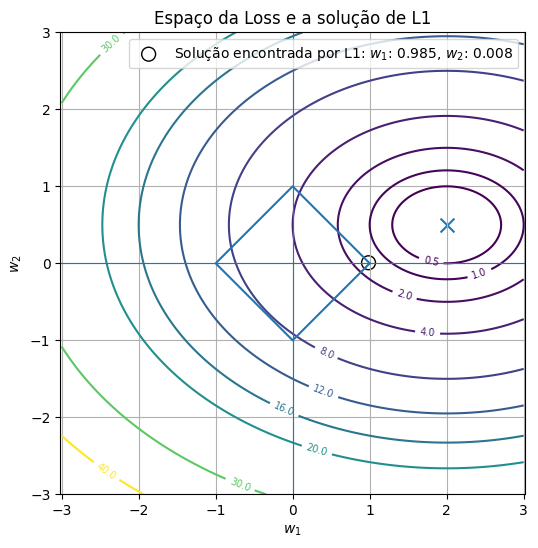

In [ ]:
plt.figure(figsize=(6, 6))

contorno = plt.contour(
    W1,
    W2,
    J,
    levels=[ 0.5, 1, 2, 4, 8, 12, 16, 20, 30, 40]
)

plt.clabel(contorno, inline=True, fontsize=7)

plt.plot(l1_w1, l1_w2)

plt.scatter(2, 0.5, marker="x", s=100)
plt.scatter(w_l1[0], w_l1[1], marker="o", facecolor="none", edgecolors="black", s=100, label= fr"Solução encontrada por L1: $w_1$: {w_l1[0]:.3f}, $w_2$: {w_l1[1]:.3f}")

plt.xlabel(r"$w_1$")
plt.ylabel(r"$w_2$")
plt.title("Espaço da Loss e a solução de L1")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.axis("equal")
plt.legend()
plt.grid()
plt.show()

Isso define um n-cross-polytope, que é uma forma geral de um octaedro preenchido de n dimensões, ou um losango preenchido no caso de n=2, dentro do espaço (<a id='toc0_'></a>[[3]](#toceq_3_), especificamente a figura 3.11). Algo interessante dessa forma geométrica é que suas quinas definem pontos onde algum dos pesos é $0$, isso é uma característica extremamente importante para o modelo. Se as curvas de nível forem analisadas para $J(w)$, nota-se que, para $J(w)=c$, o primeiro ponto a ser tocado, que também é solução para (8), normalmente é uma das quinas. Isso não é regra, já que não há nenhuma restrição dessa tangencia ocorrer no meio da aresta, porém, o L1 favorece esse tipo de solução. Isso significa que, ao diminuir a loss, o primeiro ponto a ser usado como resposta tem algum peso zero ou próximo disso. Com isso, fica evidente que L1 presa por esparsidade.

Ademais, isso pode ser visualizado pela derivada da equação. Porém, deve-se ter cuidado ao derivar esse $R(w)$, já que essa função não é derivável em todo o seu domínio, por isso, deve-se separa-la em três partes:

$$\frac{d R(w)}{dw}=1 \text{ para }w>0$$
$$\frac{d R(w)}{dw}=-1 \text{ para }w<0$$

Ambas formulas são facilmente deriváveis, mas o que ocorre em $R(0)$? Essa função não é derivável em $0$, mas isso não significa que não exista forma de extrair uma solução. Usando o conceito de subgradiente <a id='toc0_'></a>[[6]](#toceq_6_) <a id='toc0_'></a>[{1}](#tocap_1_), vemos que:

$$\partial |w|_{w=0}=[-1,1]\text{, logo, }\lambda R(w)\text{ será: } \partial \lambda |w|_{w=0}=[-\lambda,\lambda]$$

Com isso, podemos avaliar qual a condição de ótimo dessa função. Vamos derivar a função $J_{L1}(w)$, para o ponto de ótimo queremos aproximadamente $0 \in \partial J(w)$, isso significa:

$$0 \in \frac{\partial J(w)}{\partial w} + [-\lambda, \lambda]$$

Isso só é possível para a condição (9).

$$(9)\qquad |\frac{\partial J(w)}{\partial w}| \leq \lambda$$

Essa inequação é mais poderosa do que parece. Ela mostra que, para gradientes suficientemente pequenos, o gradiente naquela posição possui magnitude menor ou igual a $\lambda$, então $\omega = 0$ é solução de ótimo para aquela posição. Logo, a regularização L1 também nulifica features que são pequenas demais para justificar a sua existência. Diferente da regularização L2, em que o caso $\frac{\partial J(w)}{\partial w}+\lambda w=0$ tem de forma pontual a solução $w=0$, L1 tem essa solução dentro de um intervalo todo.

Por isso, a regularização L1 realiza uma seleção de features e zera os coeficientes associados as features que não contribuem para a solução. Isso é fantástico principalmente para problemas sub-determinado, já que L1 elimina uma parte dos parâmetros que os exemplos não explicam, ajudando a aumentar a eficacia dos exemplos e, em casos de uma regressão linear, possibilita aproximar uma boa solução para o problema que antes era posto como sem solução determinada <a id='toc0_'></a>[[3]](#toceq_3_) <a id='toc0_'></a>[[5]](#toceq_5_).

Pela mesma razão, regularização L1 é capaz de evitar overfitting. Ela assume que a verdadeira solução do problema é aproximadamente esparsa.

Essa discussão é extremamente valiosa para o entendimento teórico, mas ainda apenas tangencia o uso prático do L1. Se quisermos convergir o modelo e calcular o erro, como fazemos o gradiente dessa função $R(w)$? Para isso, vamos analisar caso a caso como a derivada de $R(w)$ se comporta.

1. Caso $w>0$: $\nabla J_{L1}(w)=\nabla J(w) + \lambda$

2. Caso $w<0$: $\nabla J_{L1}(w)=\nabla J(w) - \lambda$

3. Caso $w=0$: $\nabla J_{L1}(w)\in \nabla J(w) - \lambda[-1,1]$

Como $J(w)=\frac{1}{2}(w-z)^2$ (vamos olhar peso a peso para ter uma análise mais minuciosa), com z sendo a resposta do ponto analisado, a derivada de $J_{L1}(w)$ ficaria $(w-z)+R'(w)$. Agora, a pergunta é: existe algum $w$ que resulta em $J'_{L1}(w)=0$ ?

Para 1., a solução seria $z-\lambda$, mas isso não é solução para todo $z$, somente para $z>\lambda$, de forma análoga, para 2., a solução também é única $w=z+\lambda$ e necessita da condição $z<-\lambda$. Agora, para o caso 3. é feita uma operação de conjuntos, resultando na condição $0\in [-z-\lambda, -z+\lambda]$, isso significa que z tem a condição de $-\lambda \leq z \leq \lambda$.

Com isso, temos a função por partes:

$$w(z)=
\begin{cases}
z - \lambda \text{, para }z>\lambda \\
0 \text{, para } -\lambda \leq z \leq \lambda \\
z+\lambda \text{, para } z<-\lambda
\end{cases}
$$

Teoricamente, isso já é uma formula resultante para a solução ótima por partes. Contudo, existe uma forma mais compacta para essa equação. Para preservar a forma da função, usa-se $max(|z|-\lambda, 0)$, isso da consistência no resultado, já que para $z>\lambda$, $-\lambda \leq z \leq \lambda$, e $z<-\lambda$ os resultados ficam consistentes para um $|w|$. Para recuperar o sinal, usa-se uma função chamada $sign(x)$. Ela é definida da seguinte forma:

$$sign(x)=
\begin{cases}
\ \ \ 1 \text{, para }x>0 \\
\ \ \ 0 \text{, para } x=0 \\
-1 \text{, para } x<0
\end{cases}
$$

Assim, a formula final dos pesos depois da regularização L1 é dado por (10). O nome dela é **soft-threshold**, já que ela tenta se aproximar suavemente em uma resposta que passe por um threshold, dando o nome para a função. Não confunda o suave com a definição matemática de diferenciabilidade, já que isso seria falso nessa função, e nem que ele é o motivo para o termo **soft** da expressão. Esse termo vem de uma comparação com outro regularizador chamado **hard-threshold**, o qual não será desenvolvido aqui.

$$(10)\qquad w_{i}(z)=sign(z)max(|z|-\lambda,0)\qquad$$

<a id='toc0_'></a>[[5]](#toceq_5_)

Essa função se apresenta como um deslocamento da reta de peso com o centro dela zerado, veja mais abaixo.

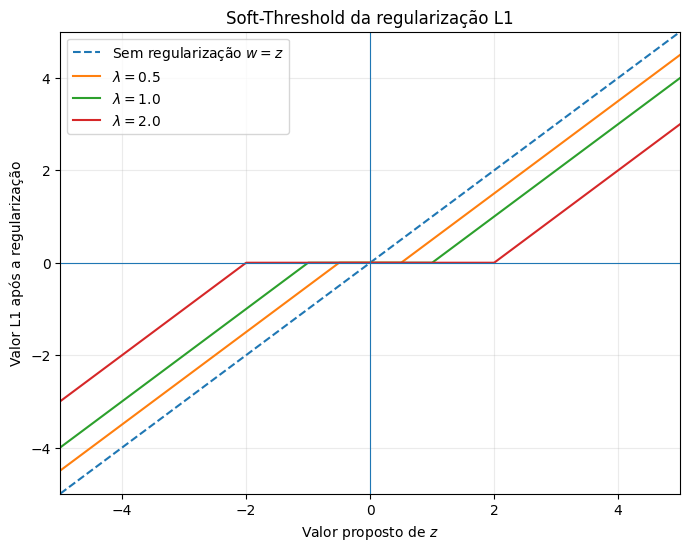

In [ ]:

z=np.linspace(-5, 5, 1000)

lambdas = [0.5, 1.0, 2.0]

plt.figure(figsize=(8,6))

plt.plot(
    z,
    z,
    linestyle="--",
    label=r"Sem regularização $w=z$"
)

for lam in lambdas:
    w = np.sign(z)*np.maximum(abs(z)-lam,0)

    plt.plot(
        z,
        w,
        label= rf"$\lambda ={lam}$"
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"Valor proposto de $z$")
plt.ylabel("Valor L1 após a regularização")
plt.title("Soft-Threshold da regularização L1")

plt.ylim(-5, 5)
plt.xlim(-5, 5)
plt.grid(alpha=0.25)
plt.legend()

plt.show()

Não podemos confundir essa formula com a "derivada" de L1, a função dada por $R(w)$ continua sem derivada continua. Então, como aplicar essa formula? Imagine uma função Loss total dada por $F(w)=f(w)+\lambda |w|$, para analisarmos o proximo passo da descida do gradiente, fazemos $z=w_t-\eta f'(w_t)$. Com esse novo $z$, passamos a escutar a regularização L1 para julgar esse passo, fazemos

$$w_{t+1}=argmin_{w}[\frac{1}{2\eta}(w-z)^2+\lambda |w|]$$

Cada termo tem uma preferencia clara, o primeiro termo $\frac{1}{2\eta}(w-z)^2$ tenta não se afastar da direção que os dados prevem e o segundo termo $\lambda |w|$ busca minimizar $w$. Nesse caso que um termo de $\eta$ surgiu, isso significa que o nosso threshold mudou. Como estamos fazendo $w_t-\eta \nabla f(w_t)$, o termo de threshold muda para $\eta \lambda$, A solução para a equação acima está na equação (10), logo, a formula final de $w_{t+1}$ é dada por (11).

$$(11)\qquad w_{t+1}=sign(w_t-\eta f'(w_t))max(|w_t-\eta f'(w_t)|-\eta\lambda, 0)$$

Contudo, e se o fenômeno real for distribuído de tal forma que todos os parâmetros tem interações muito limitadas, mas essenciais? Infelizmente, casos como esses podem fazer com que o L1 descarte informação útil, por isso, devemos pensar **eu realmente acredito que a solução do meu problema é esparsa?** Ademais, o fato de uma característica ser eliminada por L1 não significa que ela não tenha informação útil. Em caso de sistemas mal-condicionados, a regularização L1 pode detectar informação redundante e decidir que um parâmetro explica tanto quanto outro.

Além disso, sem padronização L1 pode penalizar termos de forma desigual baseado na unidade. Imagine a uma altura em metros e outras em milímetros, o regularizador L1 tende a preferir uma altura em milímetros simplesmente pela magnitude <a id='toc0_'></a>[[1]](#toceq_1_) <a id='toc0_'></a>[[3]](#toceq_3_). Por isso, devemos nos atentar a comparar dados não padronizados, já que algumas não fazem sentido.

Fora em casos de ortogonalidade, uma estratégia comum para resolver Lasso (L1) é *Coordinate Descent*, que é parecido com o *Gradient Descent*, mas atualiza peso a peso em sequência ao invés de dar um passo na direção de um vetor específico. Essa técnica é a utilizada pela principal biblioteca desse notebook, o ``scikit-learn`` 

Com tudo isso, como podemos aplicar-los? 